###import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

###Load datasets

In [2]:
# Transaction Dataset
df = pd.read_csv("analysis data.csv")

# RFM Dataset
rfm = pd.read_csv("RFM_Customer_Segmentation.csv")

In [3]:
print("Transaction Dataset Shape:", df.shape)

df.head()

Transaction Dataset Shape: (12020, 39)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,purchase_year,purchase_month,purchase_quarter,purchase_day,delivery_days,delivery_delay,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,0.0,Unknown,Unknown,2017-03-15 23:39:26,0.0,0.00,0.0,1.0,credit_card,1.0,18.12,Unknown,52.0,601.0,1.0,700.0,25.0,13.0,20.0,Unknown,2017.0,10.0,4.0,2.0,8.0,-8.0,On Time
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,0.0,Unknown,Unknown,2017-03-15 23:39:26,0.0,0.00,0.0,3.0,voucher,1.0,2.00,Unknown,52.0,601.0,1.0,700.0,25.0,13.0,20.0,Unknown,2017.0,10.0,4.0,2.0,8.0,-8.0,On Time
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,0.0,Unknown,Unknown,2017-03-15 23:39:26,0.0,0.00,0.0,2.0,voucher,1.0,18.59,Unknown,52.0,601.0,1.0,700.0,25.0,13.0,20.0,Unknown,2017.0,10.0,4.0,2.0,8.0,-8.0,On Time
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.7,22.76,118.7,1.0,boleto,1.0,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,2018.0,7.0,3.0,24.0,13.0,-6.0,On Time
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.9,19.22,159.9,1.0,credit_card,3.0,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,2018.0,8.0,3.0,8.0,9.0,-18.0,On Time


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12020 entries, 0 to 12019
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       12020 non-null  object 
 1   customer_id                    12020 non-null  object 
 2   order_status                   12020 non-null  object 
 3   order_purchase_timestamp       12020 non-null  object 
 4   order_approved_at              12020 non-null  object 
 5   order_delivered_carrier_date   12020 non-null  object 
 6   order_delivered_customer_date  12020 non-null  object 
 7   order_estimated_delivery_date  12020 non-null  object 
 8   customer_unique_id             12020 non-null  object 
 9   customer_zip_code_prefix       12020 non-null  int64  
 10  customer_city                  12020 non-null  object 
 11  customer_state                 12020 non-null  object 
 12  order_item_id                  12019 non-null 

In [5]:
df.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,revenue,payment_sequential,payment_installments,payment_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,purchase_year,purchase_month,purchase_quarter,purchase_day,delivery_days,delivery_delay
count,12020.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000,12019.000000
mean,34823.812313,0.967219,98.843118,16.479208,98.843118,1.098677,2.913138,167.911106,49.192528,753.435727,1.996090,1868.780181,29.328314,15.960646,22.490973,2017.537482,6.041684,2.355687,15.672768,11.911557,-12.003578
std,29625.545911,0.693447,174.886431,16.040154,174.886431,0.718545,2.732504,240.414267,9.477814,591.090762,1.633676,3452.686137,14.852535,12.363707,10.981610,0.505410,3.248822,1.066379,8.699788,9.068300,9.693235
min,1003.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,10.000000,20.000000,1.000000,0.000000,7.000000,2.000000,9.000000,2016.000000,1.000000,1.000000,1.000000,0.000000,-69.000000
25%,11520.000000,1.000000,23.450000,8.720000,23.450000,1.000000,1.000000,60.420000,45.000000,395.000000,1.000000,350.000000,19.000000,10.000000,15.000000,2017.000000,3.000000,1.000000,8.000000,6.000000,-17.000000
50%,24115.000000,1.000000,58.670000,15.100000,58.670000,1.000000,2.000000,105.900000,52.000000,601.000000,1.000000,700.000000,25.000000,13.000000,20.000000,2018.000000,6.000000,2.000000,16.000000,10.000000,-13.000000
75%,58050.500000,1.000000,118.000000,19.320000,118.000000,1.000000,4.000000,184.830000,56.000000,891.000000,2.000000,1500.000000,35.000000,19.000000,26.000000,2018.000000,8.000000,3.000000,23.000000,15.000000,-7.000000
max,99950.000000,12.000000,4059.000000,322.100000,4059.000000,22.000000,24.000000,6726.660000,64.000000,3988.000000,18.000000,30000.000000,105.000000,105.000000,104.000000,2018.000000,12.000000,4.000000,31.000000,143.000000,112.000000


In [6]:
print("RFM Dataset Shape:", rfm.shape)

rfm.head()

RFM Dataset Shape: (6263, 9)


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,00082cbe03e478190aadbea78542e933,305,1,79.00,2,1,3,213,Need Attention
1,00191a9719ef48ebb5860b130347bf33,520,1,47.90,1,1,3,113,Need Attention
2,0019e8c501c85848ac0966d45226fa1d,143,1,159.99,4,1,5,415,Need Attention
3,0023557a94bef0038066b5d1b3dc763e,176,1,0.00,4,1,1,411,Need Attention
4,0032ca69771a7758ce643258bb9e4ac7,66,1,45.00,5,1,2,512,Need Attention


In [7]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6263 entries, 0 to 6262
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  6263 non-null   object 
 1   Recency     6263 non-null   int64  
 2   Frequency   6263 non-null   int64  
 3   Monetary    6263 non-null   float64
 4   R_Score     6263 non-null   int64  
 5   F_Score     6263 non-null   int64  
 6   M_Score     6263 non-null   int64  
 7   RFM_Score   6263 non-null   int64  
 8   Segment     6263 non-null   object 
dtypes: float64(1), int64(6), object(2)
memory usage: 440.5+ KB


In [8]:
rfm.describe()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
count,6263.000000,6263.000000,6263.000000,6263.000000,6263.000000,6263.000000,6263.000000
mean,261.891905,1.001916,111.568399,3.002874,3.000000,2.999202,333.286604
std,155.134216,0.047244,199.048424,1.415227,1.414439,1.413592,142.367758
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,111.000000
25%,136.000000,1.000000,21.990000,2.000000,2.000000,2.000000,222.000000
50%,242.000000,1.000000,60.000000,3.000000,3.000000,3.000000,333.000000
75%,372.000000,1.000000,129.900000,4.000000,4.000000,4.000000,445.000000
max,746.000000,3.000000,4059.000000,5.000000,5.000000,5.000000,555.000000


In [9]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

,0
order_item_id,1
product_id,1
seller_id,1
shipping_limit_date,1
price,1
freight_value,1
revenue,1
payment_sequential,1
payment_type,1
payment_installments,1


In [10]:
rfm.isnull().sum()

,0
CustomerID,0
Recency,0
Frequency,0
Monetary,0
R_Score,0
F_Score,0
M_Score,0
RFM_Score,0
Segment,0


In [11]:
df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'revenue',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'purchase_year',
 'purchase_month',
 'purchase_quarter',
 'purchase_day',
 'delivery_days',
 'delivery_delay',
 'delivery_status']

In [12]:
rfm.columns.tolist()

['CustomerID',
 'Recency',
 'Frequency',
 'Monetary',
 'R_Score',
 'F_Score',
 'M_Score',
 'RFM_Score',
 'Segment']

In [13]:
for col in df.columns:
    print(col)

order_id
customer_id
order_status
order_purchase_timestamp
order_approved_at
order_delivered_carrier_date
order_delivered_customer_date
order_estimated_delivery_date
customer_unique_id
customer_zip_code_prefix
customer_city
customer_state
order_item_id
product_id
seller_id
shipping_limit_date
price
freight_value
revenue
payment_sequential
payment_type
payment_installments
payment_value
product_category_name
product_name_lenght
product_description_lenght
product_photos_qty
product_weight_g
product_length_cm
product_height_cm
product_width_cm
product_category_name_english
purchase_year
purchase_month
purchase_quarter
purchase_day
delivery_days
delivery_delay
delivery_status


In [14]:
for col in rfm.columns:
    print(col)

CustomerID
Recency
Frequency
Monetary
R_Score
F_Score
M_Score
RFM_Score
Segment


In [15]:
print("Unique Customers:", df['customer_unique_id'].nunique())

Unique Customers: 10354


In [16]:
print("Unique Customers:", rfm['CustomerID'].nunique())

Unique Customers: 6263


In [17]:
rfm['Segment'].value_counts()

,count
Segment,
Need Attention,1870
At Risk,1492
Loyal Customers,1098
Potential Loyalists,981
Champions,429
Lost Customers,393


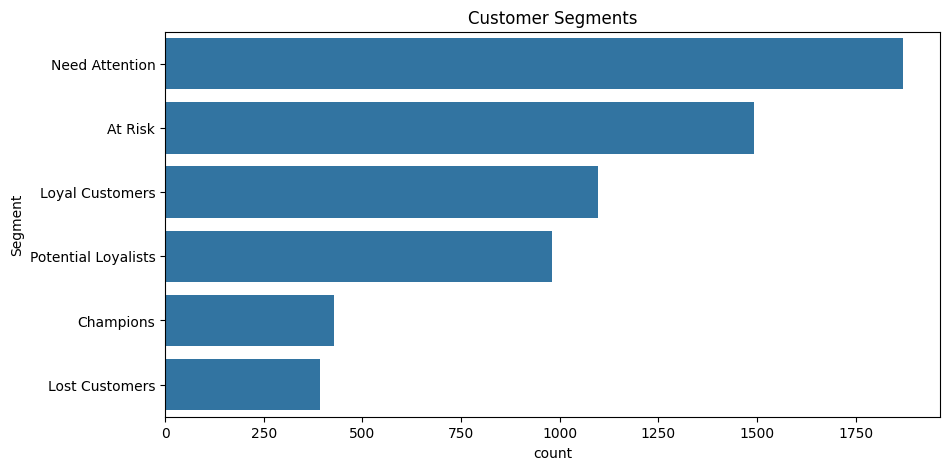

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=rfm,
    y='Segment',
    order=rfm['Segment'].value_counts().index
)

plt.title("Customer Segments")
plt.show()

###create churn label

**Churn = 1**

Lost Customers

At Risk

**Churn = 0**

All Other Segments

In [19]:
churn_segments = [
    'Lost Customers',
    'At Risk'
]

rfm['Churn'] = rfm['Segment'].apply(
    lambda x: 1 if x in churn_segments else 0
)

rfm['Churn'].value_counts()

,count
Churn,
0,4378
1,1885


###churn Distribution

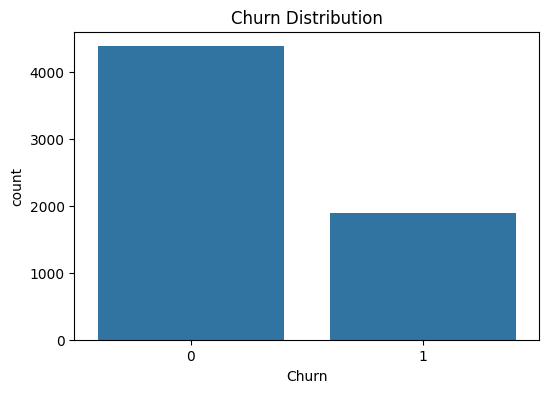

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=rfm,
    x='Churn'
)

plt.title("Churn Distribution")
plt.show()

In [21]:
print(df['customer_unique_id'].head())
print(rfm['CustomerID'].head())

0    7c396fd4830fd04220f754e42b4e5bff
1    7c396fd4830fd04220f754e42b4e5bff
2    7c396fd4830fd04220f754e42b4e5bff
3    af07308b275d755c9edb36a90c618231
4    3a653a41f6f9fc3d2a113cf8398680e8
Name: customer_unique_id, dtype: object
0    00082cbe03e478190aadbea78542e933
1    00191a9719ef48ebb5860b130347bf33
2    0019e8c501c85848ac0966d45226fa1d
3    0023557a94bef0038066b5d1b3dc763e
4    0032ca69771a7758ce643258bb9e4ac7
Name: CustomerID, dtype: object


In [22]:
common_customers = set(df['customer_unique_id']).intersection(
    set(rfm['CustomerID'])
)

print("Matching Customers:", len(common_customers))

Matching Customers: 6263


In [23]:
print("Transaction Customers:",
      df['customer_unique_id'].nunique())

print("RFM Customers:",
      rfm['CustomerID'].nunique())

Transaction Customers: 10354
RFM Customers: 6263


###create the merge

In [24]:
merged_df = pd.merge(
    rfm,
    df,
    left_on='CustomerID',
    right_on='customer_unique_id',
    how='left'
)

print(merged_df.shape)

(7238, 49)


In [25]:
merged_df[['CustomerID','customer_unique_id']].head()

,CustomerID,customer_unique_id
0,00082cbe03e478190aadbea78542e933,00082cbe03e478190aadbea78542e933
1,00191a9719ef48ebb5860b130347bf33,00191a9719ef48ebb5860b130347bf33
2,0019e8c501c85848ac0966d45226fa1d,0019e8c501c85848ac0966d45226fa1d
3,0023557a94bef0038066b5d1b3dc763e,0023557a94bef0038066b5d1b3dc763e
4,0032ca69771a7758ce643258bb9e4ac7,0032ca69771a7758ce643258bb9e4ac7


###create churn variable

In [26]:
churn_segments = ['Lost Customers', 'At Risk']

merged_df['Churn'] = merged_df['Segment'].apply(
    lambda x: 1 if x in churn_segments else 0
)

merged_df['Churn'].value_counts()

,count
Churn,
0,5063
1,2175


In [27]:
def risk_level(segment):

    if segment in ['Lost Customers', 'At Risk']:
        return 'High Risk'

    elif segment in ['Need Attention']:
        return 'Medium Risk'

    else:
        return 'Low Risk'

merged_df['Risk_Level'] = merged_df['Segment'].apply(risk_level)

merged_df['Risk_Level'].value_counts()

,count
Risk_Level,
Low Risk,2867
Medium Risk,2196
High Risk,2175


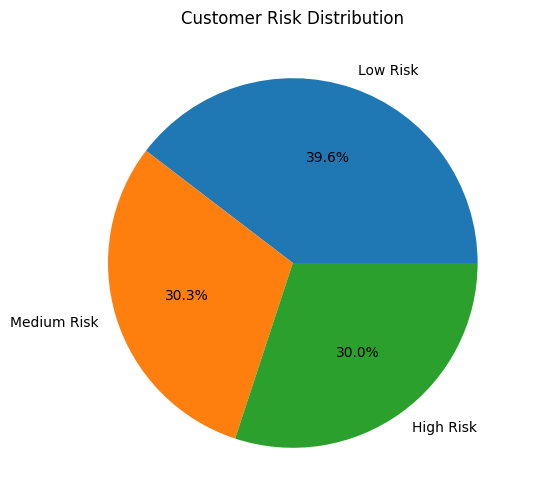

In [28]:
import matplotlib.pyplot as plt

risk_counts = merged_df['Risk_Level'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%'
)
plt.title('Customer Risk Distribution')
plt.show()

###state wise churn rate

In [29]:
customer_state = merged_df.groupby(
    ['CustomerID','customer_state']
).agg(
    Churn=('Churn','max')
).reset_index()

In [30]:
state_churn = customer_state.groupby(
    'customer_state'
).agg(
    Total_Customers=('CustomerID','count'),
    Churned_Customers=('Churn','sum')
).reset_index()

state_churn['Churn_Rate'] = (
    state_churn['Churned_Customers']
    /
    state_churn['Total_Customers']
) * 100

state_churn.sort_values(
    'Churn_Rate',
    ascending=False
).head(10)

,customer_state,Total_Customers,Churned_Customers,Churn_Rate
20,RO,11,7,63.636364
0,AC,8,4,50.000000
1,AL,33,13,39.393939
13,PA,66,24,36.363636
24,SE,31,11,35.483871
12,MT,49,17,34.693878
22,RS,343,115,33.527697
4,BA,215,72,33.488372
2,AM,3,1,33.333333
8,GO,135,45,33.333333


###Revenue at Risk

In [31]:
high_risk = merged_df[
    merged_df['Risk_Level'] == 'High Risk'
]

revenue_at_risk = high_risk['revenue'].sum()

print("Revenue At Risk:", revenue_at_risk)

Revenue At Risk: 166316.5


###state

In [32]:
risk_revenue = high_risk.groupby(
    'customer_state'
)['revenue'].sum().reset_index()

risk_revenue.sort_values(
    'revenue',
    ascending=False
).head(10)

,customer_state,revenue
24,SP,62780.07
17,RJ,28495.98
9,MG,16279.43
16,PR,10587.19
21,RS,9611.27
3,BA,5342.18
22,SC,4716.81
7,GO,4229.57
4,CE,4098.35
5,DF,3288.12


###Top high-risk customers

In [33]:
top_high_risk = merged_df[
    merged_df['Risk_Level'] == 'High Risk'
][[
    'CustomerID',
    'customer_state',
    'Monetary',
    'Recency',
    'Frequency',
    'Segment'
]]

top_high_risk = top_high_risk.drop_duplicates()

top_high_risk.sort_values(
    'Monetary',
    ascending=False
).head(20)

,CustomerID,customer_state,Monetary,Recency,Frequency,Segment
3830,895617ab63a9ad8881d9470f7427cd25,PR,2999.99,350,1,At Risk
3063,6d443b75cff956bb73dce7385033e266,SP,2105.40,381,1,At Risk
5538,c5365631fcd0f5ae1802e798e1b7d692,PR,1736.00,357,1,At Risk
3500,7e251bdcd9072568271fe5b5b824b6be,RJ,1499.99,383,1,At Risk
6298,df030c3c1d42349bb0a40197e53316ab,MT,1340.00,324,1,At Risk
5119,b61b38d88ef98dd66fc100efabad2557,MG,1200.00,388,1,At Risk
5425,c114c44566c2d172b520bc3c8785ffdf,SP,1199.90,500,1,At Risk
6544,e6aede5b2818df1b512845c729cf7463,SP,1098.00,296,1,At Risk
7189,feb2a9889d236875c3510880bf9576f3,DF,958.99,501,1,At Risk
6691,eb679f5c31d49d7a27b04db1e948b959,RJ,899.99,351,1,At Risk


###churn prediction model

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

X = merged_df[
    ['Recency',
     'Frequency',
     'Monetary',
     'R_Score',
     'F_Score',
     'M_Score',
     'RFM_Score']
]

y = merged_df['Churn']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:,1]

###model evaluation

In [37]:
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, prob))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 0.9999999999999999


In [38]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance)

     Feature  Importance
6  RFM_Score    0.306362
3    R_Score    0.217647
0    Recency    0.213338
4    F_Score    0.158612
2   Monetary    0.052058
5    M_Score    0.051945
1  Frequency    0.000037


###customers

In [39]:
lost_customers = rfm[
    rfm['Segment'] == 'Lost Customers'
]['CustomerID'].nunique()

print("Lost Customers:", lost_customers)

Lost Customers: 393


In [40]:
at_risk_customers = rfm[
    rfm['Segment'] == 'At Risk'
]['CustomerID'].nunique()

print("At Risk Customers:", at_risk_customers)

At Risk Customers: 1492


In [41]:
high_risk_customers = rfm[
    rfm['Segment'].isin(['Lost Customers', 'At Risk'])
]['CustomerID'].nunique()

print("High Risk Customers:", high_risk_customers)

High Risk Customers: 1885


In [42]:
segment_summary = (
    rfm.groupby('Segment')['CustomerID']
       .nunique()
       .reset_index(name='Customer_Count')
       .sort_values('Customer_Count', ascending=False)
)

print(segment_summary)

               Segment  Customer_Count
4       Need Attention            1870
0              At Risk            1492
3      Loyal Customers            1098
5  Potential Loyalists             981
1            Champions             429
2       Lost Customers             393


In [43]:
total_customers = rfm['CustomerID'].nunique()

lost_pct = (lost_customers / total_customers) * 100
at_risk_pct = (at_risk_customers / total_customers) * 100

print(f"Lost Customers: {lost_pct:.2f}%")
print(f"At Risk Customers: {at_risk_pct:.2f}%")

Lost Customers: 6.27%
At Risk Customers: 23.82%


###calculate the customer counts

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Customer Counts
lost_customers = rfm[rfm['Segment'] == 'Lost Customers']['CustomerID'].nunique()

at_risk_customers = rfm[rfm['Segment'] == 'At Risk']['CustomerID'].nunique()

total_customers = rfm['CustomerID'].nunique()

high_risk_customers = lost_customers + at_risk_customers

other_customers = total_customers - high_risk_customers

print("Total Customers:", total_customers)
print("Lost Customers:", lost_customers)
print("At Risk Customers:", at_risk_customers)
print("High Risk Customers:", high_risk_customers)

Total Customers: 6263
Lost Customers: 393
At Risk Customers: 1492
High Risk Customers: 1885


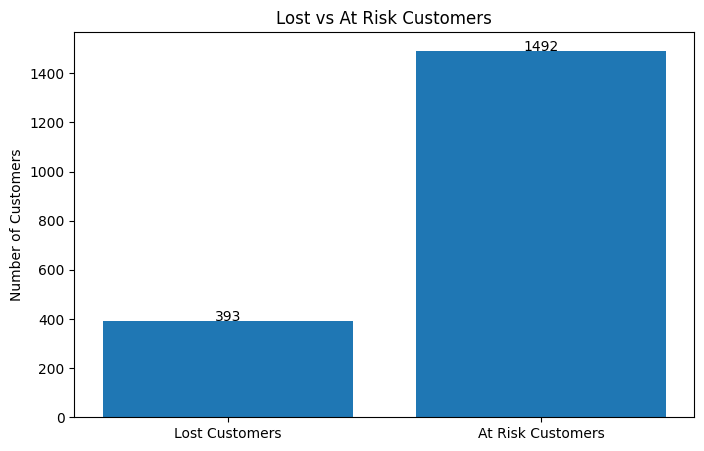

In [45]:
plt.figure(figsize=(8,5))

categories = ['Lost Customers', 'At Risk Customers']
values = [lost_customers, at_risk_customers]

bars = plt.bar(categories, values)

plt.title('Lost vs At Risk Customers')
plt.ylabel('Number of Customers')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center'
    )

plt.show()

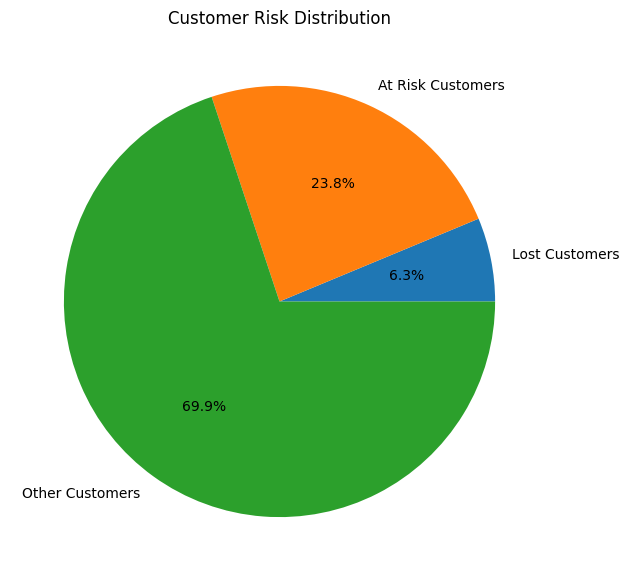

In [46]:
plt.figure(figsize=(7,7))

plt.pie(
    [lost_customers, at_risk_customers, other_customers],
    labels=[
        'Lost Customers',
        'At Risk Customers',
        'Other Customers'
    ],
    autopct='%1.1f%%'
)

plt.title('Customer Risk Distribution')

plt.show()

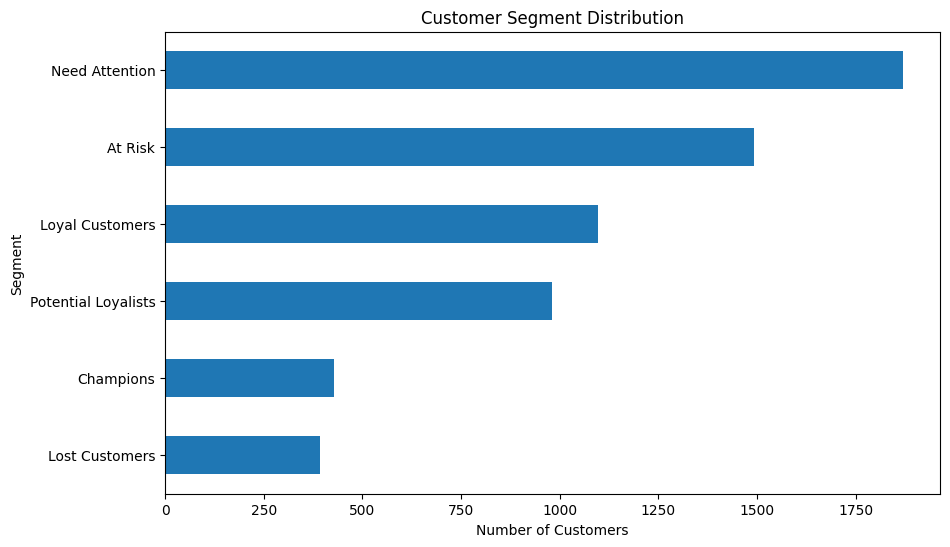

In [47]:
segment_counts = (
    rfm['Segment']
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10,6))

segment_counts.plot(kind='barh')

plt.title('Customer Segment Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')

plt.show()

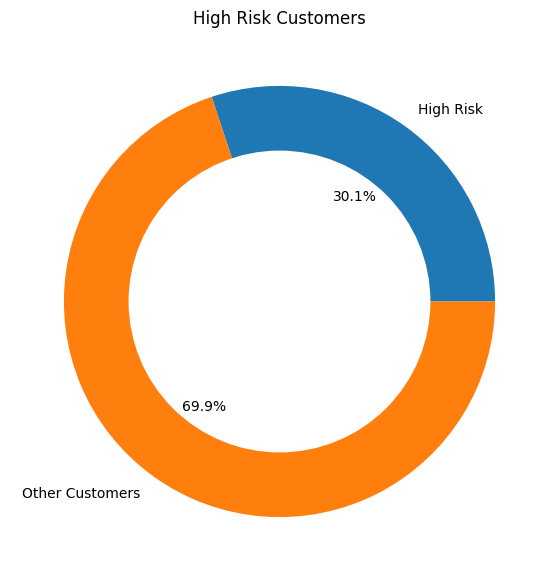

In [48]:
plt.figure(figsize=(7,7))

sizes = [high_risk_customers, other_customers]

labels = [
    'High Risk',
    'Other Customers'
]

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('High Risk Customers')

plt.show()

In [49]:
summary = pd.DataFrame({
    'Category': [
        'Lost Customers',
        'At Risk Customers',
        'High Risk Customers',
        'Other Customers'
    ],
    'Customer Count': [
        lost_customers,
        at_risk_customers,
        high_risk_customers,
        other_customers
    ]
})

summary['Percentage'] = (
    summary['Customer Count']
    /
    total_customers
) * 100

print(summary)

              Category  Customer Count  Percentage
0       Lost Customers             393    6.274948
1    At Risk Customers            1492   23.822449
2  High Risk Customers            1885   30.097397
3      Other Customers            4378   69.902603
